# COMBINED DATA FIGURE 

In [ ]:
from pynwb import NWBHDF5IO
import pandas as pd 
import matplotlib.pyplot as plt 
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
import seaborn as sns
import numpy as np 
import os
from scipy.stats import pearsonr
from scipy.stats import gaussian_kde

# Set working directory to test this out locally 
os.chdir('/Users/nicole.burke/OneDrive - Child Mind Institute/02_Projects/06_rockland_sample/01_rockland_descriptor_paper/complied_server_data')
print(os.getcwd())

### Custom functions for script 
def descr_stats(df, column_name):
    stats = df[column_name].agg(
        mean='mean',
        min='min',
        max='max',
        std='std'
    )
    print(f"Summary stats for column: {column_name}")
    print(stats)

    return stats

## The *Present* DS1

In [ ]:
#### Read in data 
present_df = pd.read_csv('present_ds1_df.csv')
present_df = present_df.iloc[:, 1:]
print(present_df.head())
print(present_df.shape)

In [ ]:
### descriptive stats 
present_number_subjects = len(present_df['subjectID'].unique())
print(f"Number of subjects in PRESENT: {present_number_subjects}")

xx = descr_stats(present_df, 'x_corr_pixels')
print("*"*10)
yy = descr_stats(present_df, 'y_corr_pixels')

In [ ]:
records = []

for subj, grp in present_df.groupby("subjectID"):
    grp = grp.sort_values("times").reset_index(drop=True)
    # print("group variable:", grp)

    times = grp["times"].values
    x     = grp["x_corr_pixels"].values
    y     = grp["y_corr_pixels"].values

    # ── Sample rate
    diffs       = np.diff(times)
    median_dt   = np.median(diffs)
    sample_rate = 1.0 / median_dt if median_dt > 0 else np.nan

    # ── Data loss: NaN + zeros (common tracker placeholder)
    n_total     = len(grp)
    n_nan       = grp[["x_corr_pixels", "y_corr_pixels"]].isna().any(axis=1).sum()
    n_zero      = ((x == 0) & (y == 0)).sum()
    n_missing   = n_nan + n_zero
    pct_missing = n_missing / n_total * 100

    # ── Coordinate ranges
    x_min, x_max = np.nanmin(x), np.nanmax(x)
    y_min, y_max = np.nanmin(y), np.nanmax(y)

    # ── Gaze velocity (px/s) — robust noise indicator
    dx       = np.diff(x)
    dy       = np.diff(y)
    dist     = np.sqrt(dx**2 + dy**2)
    velocity = dist / diffs                        # px/s
    vel_median = np.nanmedian(velocity)
    vel_sd     = np.nanstd(velocity)
    vel_p95    = np.nanpercentile(velocity, 95)

    # ── Timestamp regularity (jitter)
    dt_sd    = np.std(diffs) * 1000                # ms jitter

    records.append({
        "subjectID"     : subj,
        "n_samples"     : n_total,
        "sample_rate_hz": round(sample_rate, 1),
        "dt_jitter_ms"  : round(dt_sd, 3),
        "pct_missing"   : round(pct_missing, 2),
        "x_min"         : round(x_min, 1),
        "x_max"         : round(x_max, 1),
        "y_min"         : round(y_min, 1),
        "y_max"         : round(y_max, 1),
        "x_range"       : round(x_max - x_min, 1),
        "y_range"       : round(y_max - y_min, 1),
        "vel_median_pxs": round(vel_median, 1),
        "vel_sd_pxs"    : round(vel_sd, 1),
        "vel_p95_pxs"   : round(vel_p95, 1),
    })

audit = pd.DataFrame(records).sort_values("x_min").reset_index(drop=True)

# print("=" * 70)
# print("PER-SUBJECT AUDIT SUMMARY: PRESENT data_structure_1")
# print("=" * 70)
# print(audit.to_string(index=False))
sampling_rate = descr_stats(audit, 'sample_rate_hz')
x_min = descr_stats(audit, 'x_min')
y_min = descr_stats(audit, 'y_min')
unique_hz = audit['sample_rate_hz'].unique().tolist()
print(f"unique sampling rate in sample: {unique_hz}")

### The *Present* FILTERED

In [ ]:
### present
# x
present_mean_x = present_df['x_corr_pixels'].mean()
present_sd_x = present_df['x_corr_pixels'].std()
print(f"present x_corr mean: {present_mean_x} and std: {present_sd_x}")
present_upper_x = present_mean_x + (present_sd_x*2.5)
present_lower_x = present_mean_x - (present_sd_x*2.5)
print(f"present x_corr upper: {present_upper_x} and lower: {present_lower_x}")
print(f"present x_corr min x: {present_df['x_corr_pixels'].min()} and max x: {present_df['x_corr_pixels'].max()}")
print(f"present number of samples: {len(present_df)}")

# filter out oultiers 
present_df_filtered = present_df[
    (present_df['x_corr_pixels'] <= present_upper_x) &
    (present_df['x_corr_pixels'] >= present_lower_x)
]
print(f"Filter present mean x: {present_df_filtered['x_corr_pixels'].mean()}, x_min: {present_df_filtered['x_corr_pixels'].min()}, x_max: {present_df_filtered['x_corr_pixels'].max()}")
print(f"Filter present number of samples lost: {len(present_df)-len(present_df_filtered)}")

print("*"*50)

# y 
present_mean_y = present_df['y_corr_pixels'].mean()
present_sd_y = present_df['y_corr_pixels'].std()
print(f"present y_corr mean: {present_mean_y} and std: {present_sd_y}")
present_upper_y = present_mean_y + (present_sd_y*2.5)
present_lower_y = present_mean_y - (present_sd_y*2.5)
print(f"present y_corr upper: {present_upper_y} and lower: {present_lower_y}")
print(f"present y_corr min y: {present_df['y_corr_pixels'].min()} and max y: {present_df['y_corr_pixels'].max()}")

# filter out outliers 
present_df_filtered = present_df_filtered[
    (present_df_filtered['y_corr_pixels'] <= present_upper_y) &
    (present_df_filtered['y_corr_pixels'] >= present_lower_y)
]
print(f"Filtered present mean y: {present_df_filtered['y_corr_pixels'].mean()}, y_min: {present_df_filtered['y_corr_pixels'].min()}, y_max: {present_df_filtered['y_corr_pixels'].max()}")
print(f"Filter present number of samples lost: {len(present_df)-len(present_df_filtered)}")
print(f"Filter present number of subjects: {len(present_df['subjectID'].unique())}")

### The *Present* Plot RAW data 

In [ ]:
plt.plot(present_df['times'], present_df['x_corr_pixels'])
plt.title("RAW Present: x_corr_pixels x Time")
plt.show()

plt.plot(present_df_filtered['times'], present_df_filtered['x_corr_pixels'])
plt.ylim(-500,1500)
plt.title("FILTERED Present: x_corr_pixels x Time")
plt.show()


### The *Present* STANDARIZED

In [4]:
# present 
present_df_standard = present_df_filtered
x_min_present = present_df_filtered['x_corr_pixels'].min()
x_max_present = present_df_filtered['x_corr_pixels'].max()
present_df_standard['x_norm'] = (present_df_standard['x_corr_pixels'] - x_min_present) / (x_max_present - x_min_present)
x_norm = descr_stats(present_df_standard, 'x_norm')

print("*"*50)

y_min_present = present_df_filtered['y_corr_pixels'].min()
y_max_present = present_df_filtered['y_corr_pixels'].max()
present_df_standard['y_norm'] = (present_df_standard['y_corr_pixels'] - y_min_present) / (y_max_present - y_min_present)
y_norm = descr_stats(present_df_standard, 'y_norm')

Summary stats for column: x_norm
mean    0.503631
min     0.000000
max     1.000000
std     0.147825
Name: x_norm, dtype: float64
**************************************************
Summary stats for column: y_norm
mean    0.492081
min     0.000000
max     1.000000
std     0.159880
Name: y_norm, dtype: float64


## The *Present* DS2

In [5]:
#### Read in data 
present_df2 = pd.read_csv('present_ds2_right_eye_df.csv')
present_df2 = present_df2.iloc[:, 1:]
print(present_df2.head())
print(present_df2.shape)

    rightEyeX   rightEyeY     times      subjectID
0  629.099976  518.599976 -1.367178  sub-A00008326
1  629.700012  519.400024 -1.365070  sub-A00008326
2  629.700012  519.400024 -1.363065  sub-A00008326
3  627.400024  524.000000 -1.361112  sub-A00008326
4  623.799988  529.200012 -1.359141  sub-A00008326
(12527062, 4)


In [ ]:
### descriptive stats 
present_number_subjects = len(present_df2['subjectID'].unique())
print(f"Number of subjects in PRESENT: {present_number_subjects}")

xx = descr_stats(present_df2, 'rightEyeX')
print("*"*10)
yy = descr_stats(present_df2, 'rightEyeY')

In [ ]:
records = []

for subj, grp in present_df2.groupby("subjectID"):
    grp = grp.sort_values("times").reset_index(drop=True)
    # print("group variable:", grp)

    times = grp["times"].values
    x     = grp["rightEyeX"].values
    y     = grp["rightEyeY"].values

    # ── Sample rate
    diffs       = np.diff(times)
    median_dt   = np.median(diffs)
    sample_rate = 1.0 / median_dt if median_dt > 0 else np.nan

    # ── Data loss: NaN + zeros (common tracker placeholder)
    n_total     = len(grp)
    n_nan       = grp[["rightEyeX", "rightEyeY"]].isna().any(axis=1).sum()
    n_zero      = ((x == 0) & (y == 0)).sum()
    n_missing   = n_nan + n_zero
    pct_missing = n_missing / n_total * 100

    # ── Coordinate ranges
    x_min, x_max = np.nanmin(x), np.nanmax(x)
    y_min, y_max = np.nanmin(y), np.nanmax(y)

    # ── Gaze velocity (px/s) — robust noise indicator
    dx       = np.diff(x)
    dy       = np.diff(y)
    dist     = np.sqrt(dx**2 + dy**2)
    velocity = dist / diffs                        # px/s
    vel_median = np.nanmedian(velocity)
    vel_sd     = np.nanstd(velocity)
    vel_p95    = np.nanpercentile(velocity, 95)

    # ── Timestamp regularity (jitter)
    dt_sd    = np.std(diffs) * 1000                # ms jitter

    records.append({
        "subjectID"     : subj,
        "n_samples"     : n_total,
        "sample_rate_hz": round(sample_rate, 1),
        "dt_jitter_ms"  : round(dt_sd, 3),
        "pct_missing"   : round(pct_missing, 2),
        "x_min"         : round(x_min, 1),
        "x_max"         : round(x_max, 1),
        "y_min"         : round(y_min, 1),
        "y_max"         : round(y_max, 1),
        "x_range"       : round(x_max - x_min, 1),
        "y_range"       : round(y_max - y_min, 1),
        "vel_median_pxs": round(vel_median, 1),
        "vel_sd_pxs"    : round(vel_sd, 1),
        "vel_p95_pxs"   : round(vel_p95, 1),
    })

audit = pd.DataFrame(records).sort_values("x_min").reset_index(drop=True)

# print("=" * 70)
# print("PER-SUBJECT AUDIT SUMMARY: PRESENT data_structure_1")
# print("=" * 70)
# print(audit.to_string(index=False))
sampling_rate = descr_stats(audit, 'sample_rate_hz')
unique_hz = audit['sample_rate_hz'].unique().tolist()
print(f"unique sampling rate in sample: {unique_hz}")

### The *Present* DS2 FILTERED 

In [6]:
### present
# x
present_mean_x = present_df2['rightEyeX'].mean()
present_sd_x = present_df2['rightEyeX'].std()
print(f"present x_corr mean: {present_mean_x} and std: {present_sd_x}")
present_upper_x = present_mean_x + (present_sd_x*2.5)
present_lower_x = present_mean_x - (present_sd_x*2.5)
print(f"present x_corr upper: {present_upper_x} and lower: {present_lower_x}")
print(f"present x_corr min x: {present_df2['rightEyeX'].min()} and max x: {present_df2['rightEyeX'].max()}")
print(f"present number of samples: {len(present_df2)}")

# filter out oultiers 
present_df2_filtered = present_df2[
    (present_df2['rightEyeX'] <= present_upper_x) &
    (present_df2['rightEyeX'] >= present_lower_x)
]
print(f"Filter present mean x: {present_df2_filtered['rightEyeX'].mean()}, x_min: {present_df2_filtered['rightEyeX'].min()}, x_max: {present_df2_filtered['rightEyeX'].max()}")
print(f"Filter present number of samples lost: {len(present_df2)-len(present_df2_filtered)}")

print("*"*50)

# y 
present_mean_y = present_df2['rightEyeY'].mean()
present_sd_y = present_df2['rightEyeY'].std()
print(f"present y_corr mean: {present_mean_y} and std: {present_sd_y}")
present_upper_y = present_mean_y + (present_sd_y*2.5)
present_lower_y = present_mean_y - (present_sd_y*2.5)
print(f"present y_corr upper: {present_upper_y} and lower: {present_lower_y}")
print(f"present y_corr min y: {present_df2['rightEyeY'].min()} and max y: {present_df2['rightEyeY'].max()}")

# filter out outliers 
present_df2_filtered = present_df2_filtered[
    (present_df2_filtered['rightEyeY'] <= present_upper_y) &
    (present_df2_filtered['rightEyeY'] >= present_lower_y)
]
print(f"Filtered present mean y: {present_df2_filtered['rightEyeY'].mean()}, y_min: {present_df2_filtered['rightEyeY'].min()}, y_max: {present_df2_filtered['rightEyeY'].max()}")
print(f"Filter present number of samples lost: {len(present_df2)-len(present_df2_filtered)}")
print(f"Filter present number of subjects: {len(present_df2['subjectID'].unique())}")

present x_corr mean: -1927.9169310710067 and std: 8921.628328148188
present x_corr upper: 20376.153889299465 and lower: -24231.987751441477
present x_corr min x: -32768.0 and max x: 2559.699951171875
present number of samples: 12527062
Filter present mean x: 651.4910385655261, x_min: -1279.5999755859375, x_max: 2559.699951171875
Filter present number of samples lost: 966873
**************************************************
present y_corr mean: -2058.0056852035495 and std: 8882.972552968735
present y_corr upper: 20149.42569721829 and lower: -24265.437067625386
present y_corr min y: -32768.0 and max y: 2046.800048828125
Filtered present mean y: 510.52189969408386, y_min: -1023.7000122070312, y_max: 2046.800048828125
Filter present number of samples lost: 966873
Filter present number of subjects: 115


### The *Present* DS2 STANDARIZED 

In [7]:
# present 
present_df2_standard = present_df2_filtered
x_min_present = present_df2_filtered['rightEyeX'].min()
x_max_present = present_df2_filtered['rightEyeX'].max()
present_df2_standard['x_norm'] = (present_df2_standard['rightEyeX'] - x_min_present) / (x_max_present - x_min_present)
x_norm = descr_stats(present_df2_standard, 'x_norm')

print("*"*50)

y_min_present = present_df2_filtered['rightEyeY'].min()
y_max_present = present_df2_filtered['rightEyeY'].max()
present_df2_standard['y_norm'] = (present_df2_standard['rightEyeY'] - y_min_present) / (y_max_present - y_min_present)
y_norm = descr_stats(present_df2_standard, 'y_norm')

Summary stats for column: x_norm
mean    0.502980
min     0.000000
max     1.000000
std     0.058335
Name: x_norm, dtype: float64
**************************************************
Summary stats for column: y_norm
mean    0.499665
min     0.000000
max     1.000000
std     0.056453
Name: y_norm, dtype: float64


## Combine *Present* DS1 and DS2

In [8]:
cols = ['times', 'subjectID', 'x_norm', 'y_norm']
present_df_merge = present_df_standard[cols]
present_df2_merge = present_df2_standard[cols]

present_combined_df = pd.concat([present_df_merge, present_df2_merge])

## The *Present* PLOT

### Calculate ISC 

In [13]:
df = present_combined_df.copy()

# --- Interpolate onto time grid (same as before) ---
time_grid = np.linspace(df['times'].min(), df['times'].max(), 500)
subjects = df['subjectID'].unique()

x_mat, y_mat = [], []
for subj in subjects:
    d = df[df['subjectID'] == subj].sort_values('times')
    x_mat.append(np.interp(time_grid, d['times'], d['x_norm']))
    y_mat.append(np.interp(time_grid, d['times'], d['y_norm']))

x_mat = np.array(x_mat)  # shape: (n_subjects, n_timepoints)
y_mat = np.array(y_mat)

n = len(subjects)

# --- Vectorized LOO mean ---
# Instead of recomputing mean of 299 subjects each time,
# subtract current subject from grand sum and divide by (n-1)
x_sum = x_mat.sum(axis=0)
y_sum = y_mat.sum(axis=0)

isc_results = []
for i, subj in enumerate(subjects):
    x_loo_mean = (x_sum - x_mat[i]) / (n - 1)
    y_loo_mean = (y_sum - y_mat[i]) / (n - 1)

    isc_x, _ = pearsonr(x_mat[i], x_loo_mean)
    isc_y, _ = pearsonr(y_mat[i], y_loo_mean)

    isc_results.append({
        "subjectID": subj,
        "ISC_x": isc_x,
        "ISC_y": isc_y,
        "ISC_mean": np.nanmean([isc_x, isc_y])
    })

isc_df = pd.DataFrame(isc_results)
# Rank by ISC_x
isc_df["rank_x"] = isc_df["ISC_x"].rank()  
isc_df["rank_y"] = isc_df["ISC_y"].rank()  
print(isc_df.head())
os.system('afplay "/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/library/beepr/sounds/smb_stage_clear.wav"')

/var/folders/xq/f83j3jh14fz6j650prgjddldpxs0f4/T/ipykernel_2413/1797650153.py:29: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  isc_x, _ = pearsonr(x_mat[i], x_loo_mean)
/var/folders/xq/f83j3jh14fz6j650prgjddldpxs0f4/T/ipykernel_2413/1797650153.py:30: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  isc_y, _ = pearsonr(y_mat[i], y_loo_mean)
/var/folders/xq/f83j3jh14fz6j650prgjddldpxs0f4/T/ipykernel_2413/1797650153.py:36: RuntimeWarning: Mean of empty slice
  "ISC_mean": np.nanmean([isc_x, isc_y])


       subjectID     ISC_x     ISC_y  ISC_mean  rank_x  rank_y
0  sub-A00010201  0.408883  0.770207  0.589545   161.0   296.0
1  sub-A00010893  0.605286  0.716113  0.660699   229.0   280.0
2  sub-A00015273  0.552216  0.064685  0.308451   212.0    81.0
3  sub-A00017133 -0.330732  0.305926 -0.012403    14.0   170.0
4  sub-A00022607 -0.030892  0.209287  0.089197    42.0   139.0


0

### Fixation X x Time 



#### Original Heatmap

In [ ]:
plt.figure(figsize=(8, 4))

plt.hexbin(
    present_combined_df['times'],
    present_combined_df['x_norm'],
    gridsize=100,
)

# Add lines: 1:57 and 2:28
line_times = [117, 148]

# Add vertical dashed red lines
for t in line_times:
    plt.axvline(x=t, color='red', linestyle='--')

plt.colorbar(label='Density')
plt.xlim(-25, 230)
plt.xlabel('Time')
plt.ylabel('X position (pixels)')
plt.title('The Present: Fixation X over Time')

plt.show()

Raw Data

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(present_combined_df["times"], present_combined_df["x_norm"], linewidth=1, color="#2563eb", alpha=0.85)

ax.set_xlabel("Time (s)", fontsize=12)
ax.set_ylabel("Standarized X Position", fontsize=12)
ax.set_title("Gaze Position Over Time", fontsize=14)

# ax.set_ylim(0, 1)  # x_norm is typically 0–1; remove if yours differs
ax.grid(True, alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()

#### Median and percentile looking

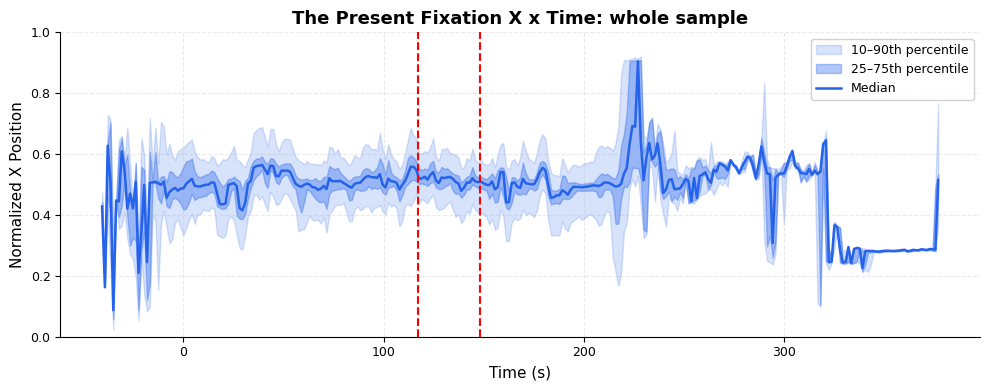

In [10]:
# --- Time bins & percentiles ---
time_bins = np.linspace(present_combined_df["times"].min(), present_combined_df["times"].max(), 300)

present_combined_df["time_bin"] = pd.cut(present_combined_df["times"], bins=time_bins, labels=time_bins[:-1]).astype(float)

grouped = present_combined_df.groupby("time_bin")["x_norm"]
t = grouped.median().index.values
median = grouped.median()
p10, p25, p75, p90 = grouped.quantile(0.10), grouped.quantile(0.25), grouped.quantile(0.75), grouped.quantile(0.90)

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 4))

ax.fill_between(t, p10, p90, alpha=0.18, color="#2563eb", label="10–90th percentile")
ax.fill_between(t, p25, p75, alpha=0.35, color="#2563eb", label="25–75th percentile")
ax.plot(t, median, color="#2563eb", linewidth=1.8, label="Median")

ax.set_xlabel("Time (s)", fontsize=11)
ax.set_ylabel("Normalized X Position", fontsize=11)
ax.set_title("The Present Fixation X x Time: whole sample", fontsize=13, fontweight="bold")
ax.set_ylim(0, 1)
# Add lines: 1:57 and 2:28
ax.axvline(x=117, color='red',linestyle='--')
ax.axvline(x=148, color='red',linestyle='--')
ax.tick_params(labelsize=9)
ax.legend(fontsize=9, framealpha=0.9, loc="upper right")
ax.grid(True, alpha=0.25, linestyle="--")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
# plt.savefig("gaze_figure.png", dpi=300, bbox_inches="tight")
plt.show()

#### Ranked by ISC

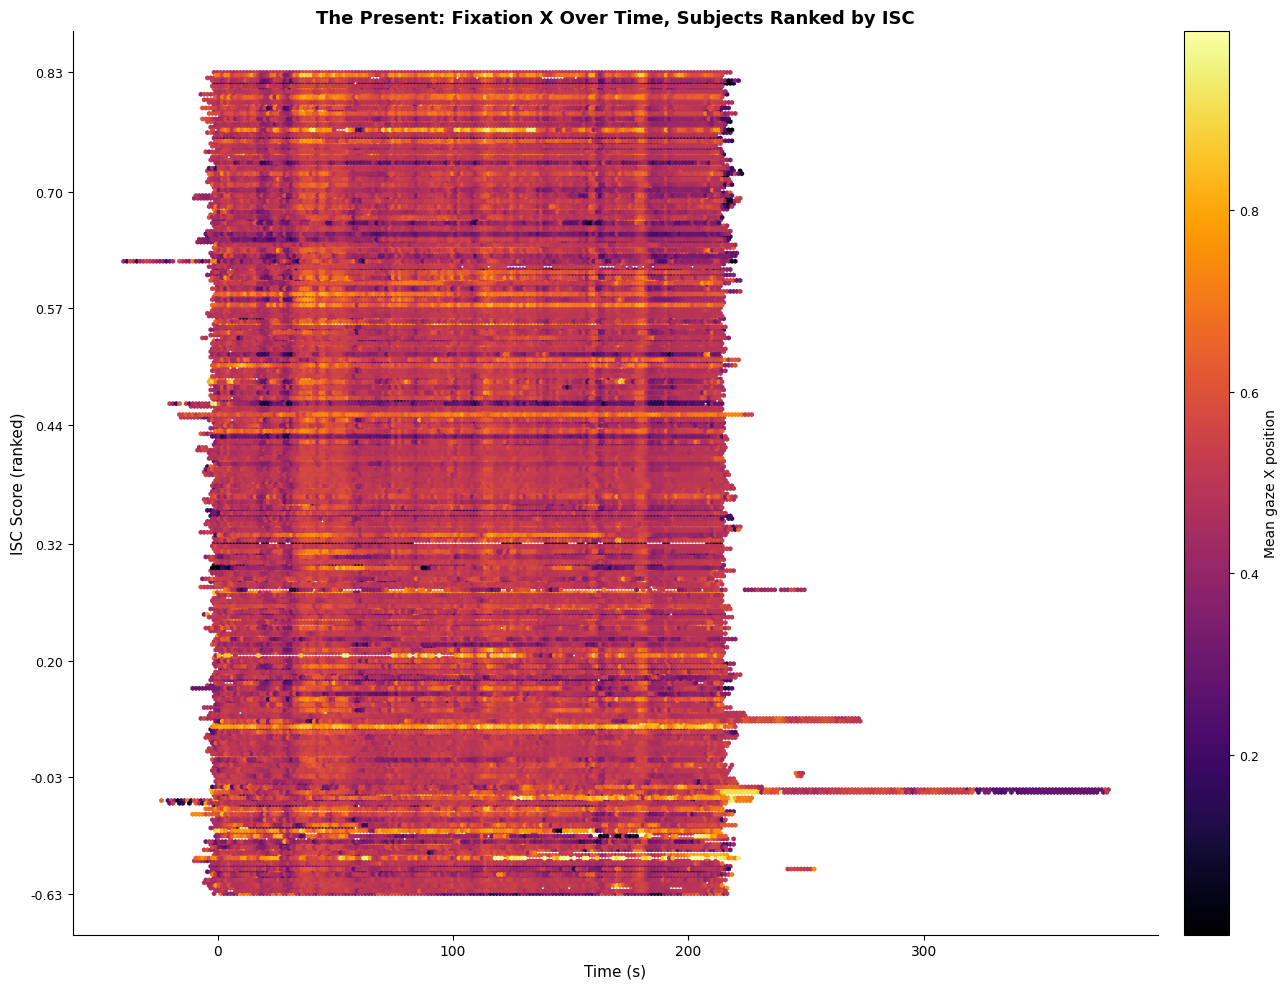

In [18]:
df = present_combined_df.merge(isc_df[["subjectID", "ISC_x", "rank_x"]], on="subjectID")

fig, ax = plt.subplots(figsize=(14, 10))

# Replace KDE loop with hexbin — fully vectorized, runs in seconds
hb = ax.hexbin(
    df["times"],
    df["rank_x"],
    C=df["x_norm"],          # color = mean x_norm in each hex cell
    gridsize=(300, 150),     # (x_bins, y_bins) — adjust for resolution
    cmap="inferno",
    reduce_C_function=np.mean,
    rasterized=True
)

cbar = fig.colorbar(hb, ax=ax, pad=0.02)
cbar.set_label("Mean gaze X position", fontsize=10)
cbar.ax.tick_params(labelsize=9)

# Y-axis: show ISC score values instead of rank integers
n_ticks = 8
# tick_ranks = np.linspace(0, df["rank_x"].max(), n_ticks, dtype=int)
tick_ranks = np.linspace(df["rank_x"].min(),
                         df["rank_x"].max(),
                         n_ticks,
                         dtype=int)
tick_labels = [f"{isc_df.loc[isc_df['rank_x'] == r, 'ISC_x'].values[0]:.2f}" for r in tick_ranks]
ax.set_yticks(tick_ranks)
ax.set_yticklabels(tick_labels, fontsize=9)

ax.set_xlabel("Time (s)", fontsize=11)
ax.set_ylabel("ISC Score (ranked)", fontsize=11)
ax.set_title("The Present: Fixation X Over Time, Subjects Ranked by ISC", fontsize=13, fontweight="bold")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
# plt.savefig("gaze_isc_ranked.pdf", dpi=300, bbox_inches="tight")
# plt.savefig("gaze_isc_ranked.png", dpi=300, bbox_inches="tight")
plt.show()

### Fixation Y x Time

#### Original Heatmap

In [ ]:
plt.figure(figsize=(8, 4))

plt.hexbin(
    present_combined_df['times'],
    present_combined_df['y_norm'],
    gridsize=100,
)

plt.colorbar(label='Density')
plt.xlim(-25, 230)
plt.xlabel('Time')
plt.ylabel('Y position (pixels)')
plt.title('The Present: Fixation Y over Time')

plt.show()

#### Median and percentile looking

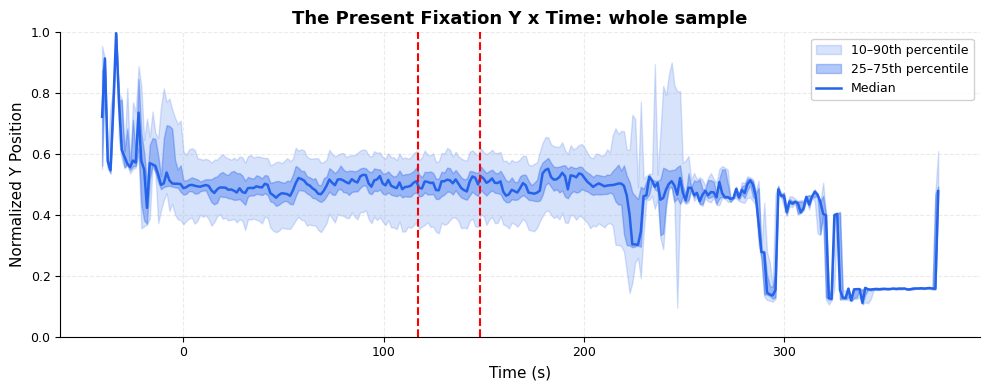

In [19]:
# --- Time bins & percentiles ---
time_bins = np.linspace(present_combined_df["times"].min(), present_combined_df["times"].max(), 300)

present_combined_df["time_bin"] = pd.cut(present_combined_df["times"], bins=time_bins, labels=time_bins[:-1]).astype(float)

grouped = present_combined_df.groupby("time_bin")["y_norm"]
t = grouped.median().index.values
median = grouped.median()
p10, p25, p75, p90 = grouped.quantile(0.10), grouped.quantile(0.25), grouped.quantile(0.75), grouped.quantile(0.90)

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 4))

ax.fill_between(t, p10, p90, alpha=0.18, color="#2563eb", label="10–90th percentile")
ax.fill_between(t, p25, p75, alpha=0.35, color="#2563eb", label="25–75th percentile")
ax.plot(t, median, color="#2563eb", linewidth=1.8, label="Median")

ax.set_xlabel("Time (s)", fontsize=11)
ax.set_ylabel("Normalized Y Position", fontsize=11)
ax.set_title("The Present Fixation Y x Time: whole sample", fontsize=13, fontweight="bold")
ax.set_ylim(0, 1)
# Add lines: 1:57 and 2:28
ax.axvline(x=117, color='red',linestyle='--')
ax.axvline(x=148, color='red',linestyle='--')
ax.tick_params(labelsize=9)
ax.legend(fontsize=9, framealpha=0.9, loc="upper right")
ax.grid(True, alpha=0.25, linestyle="--")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
# plt.savefig("gaze_figure.png", dpi=300, bbox_inches="tight")
plt.show()

#### Ranked by ISC 

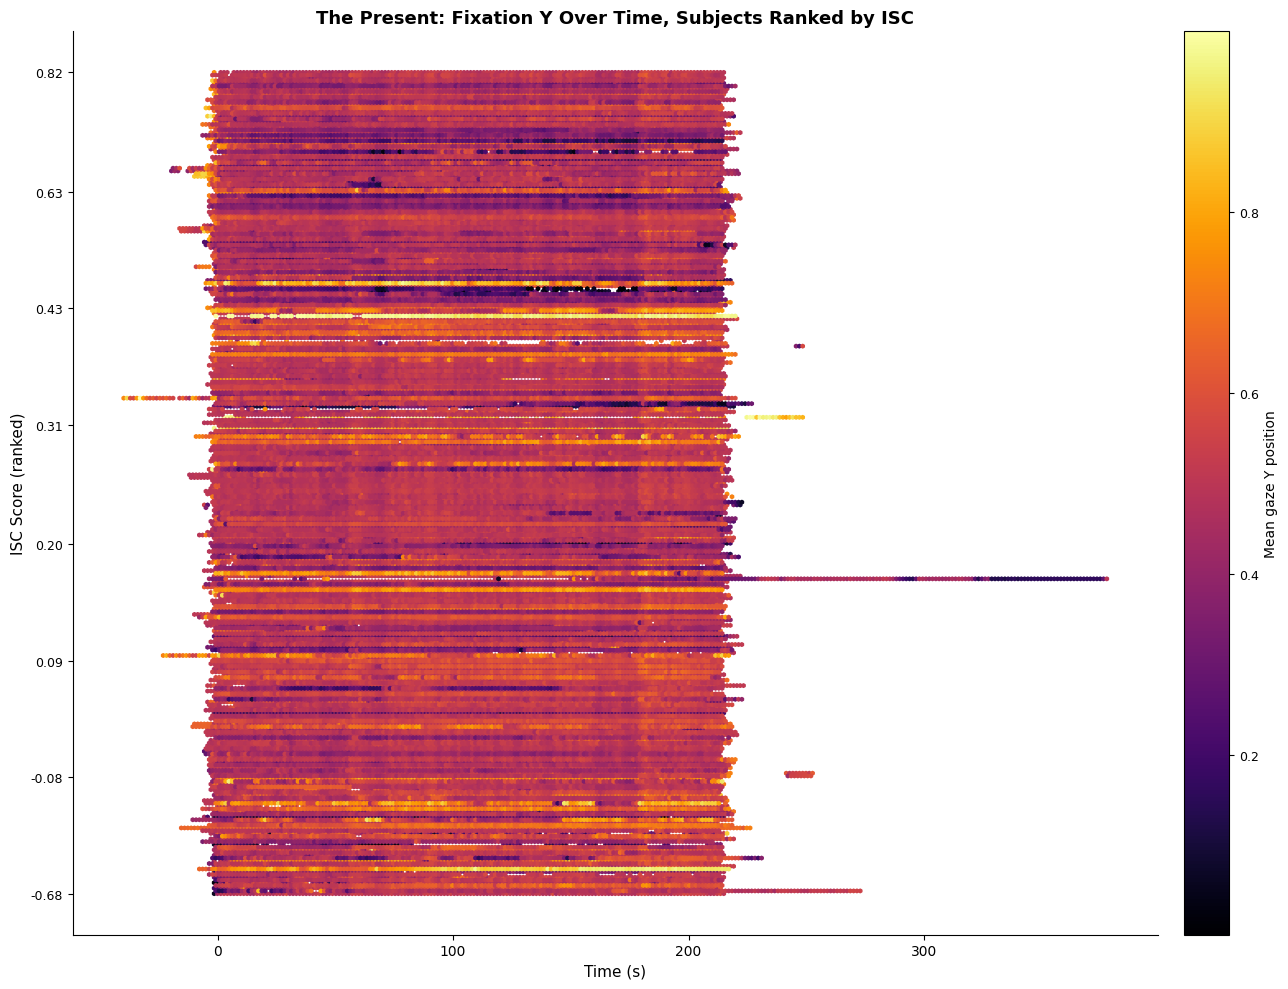

In [20]:
df = present_combined_df.merge(isc_df[["subjectID", "ISC_y", "rank_y"]], on="subjectID")

fig, ax = plt.subplots(figsize=(14, 10))

# Replace KDE loop with hexbin — fully vectorized, runs in seconds
hb = ax.hexbin(
    df["times"],
    df["rank_y"],
    C=df["y_norm"],          # color = mean x_norm in each hex cell
    gridsize=(300, 150),     # (x_bins, y_bins) — adjust for resolution
    cmap="inferno",
    reduce_C_function=np.mean,
    rasterized=True
)

cbar = fig.colorbar(hb, ax=ax, pad=0.02)
cbar.set_label("Mean gaze Y position", fontsize=10)
cbar.ax.tick_params(labelsize=9)

# Y-axis: show ISC score values instead of rank integers
n_ticks = 8
# tick_ranks = np.linspace(0, df["rank_y"].max(), n_ticks, dtype=int)
tick_ranks = np.linspace(df["rank_y"].min(),
                         df["rank_y"].max(),
                         n_ticks,
                         dtype=int)
tick_labels = [f"{isc_df.loc[isc_df['rank_y'] == r, 'ISC_y'].values[0]:.2f}" for r in tick_ranks]
ax.set_yticks(tick_ranks)
ax.set_yticklabels(tick_labels, fontsize=9)

ax.set_xlabel("Time (s)", fontsize=11)
ax.set_ylabel("ISC Score (ranked)", fontsize=11)
ax.set_title("The Present: Fixation Y Over Time, Subjects Ranked by ISC", fontsize=13, fontweight="bold")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
# plt.savefig("gaze_isc_ranked.pdf", dpi=300, bbox_inches="tight")
# plt.savefig("gaze_isc_ranked.png", dpi=300, bbox_inches="tight")
plt.show()

## *Sherlock* DS1

In [22]:
### read in data 
sherlock_df = pd.read_csv("sherlock_ds1_df.csv")
sherlock_df = sherlock_df.iloc[:, 1:]
print(sherlock_df.head())
print(sherlock_df.shape)

   x_corr_pixels  y_corr_pixels     times      subjectID
0          669.9          513.0 -0.405907  sub-A00010201
1          669.9          512.3 -0.400351  sub-A00010201
2          670.0          511.9 -0.394795  sub-A00010201
3          670.1          511.2 -0.389240  sub-A00010201
4          670.0          510.8 -0.383684  sub-A00010201
(20762676, 4)


In [ ]:
### descriptive stats 
sherlock_number_subjects = len(sherlock_df['subjectID'].unique())
print(f"Number of subjects in SHERLOCK: {sherlock_number_subjects}")

xx = descr_stats(sherlock_df, 'x_corr_pixels')
print("*"*10)
yy = descr_stats(sherlock_df, 'y_corr_pixels')

In [ ]:
records = []

for subj, grp in sherlock_df.groupby("subjectID"):
    grp = grp.sort_values("times").reset_index(drop=True)
    # print("group variable:", grp)

    times = grp["times"].values
    x     = grp["x_corr_pixels"].values
    y     = grp["y_corr_pixels"].values

    # ── Sample rate
    diffs       = np.diff(times)
    median_dt   = np.median(diffs)
    sample_rate = 1.0 / median_dt if median_dt > 0 else np.nan

    # ── Data loss: NaN + zeros (common tracker placeholder)
    n_total     = len(grp)
    n_nan       = grp[["x_corr_pixels", "y_corr_pixels"]].isna().any(axis=1).sum()
    n_zero      = ((x == 0) & (y == 0)).sum()
    n_missing   = n_nan + n_zero
    pct_missing = n_missing / n_total * 100

    # ── Coordinate ranges
    x_min, x_max = np.nanmin(x), np.nanmax(x)
    y_min, y_max = np.nanmin(y), np.nanmax(y)

    # ── Gaze velocity (px/s) — robust noise indicator
    dx       = np.diff(x)
    dy       = np.diff(y)
    dist     = np.sqrt(dx**2 + dy**2)
    velocity = dist / diffs                        # px/s
    vel_median = np.nanmedian(velocity)
    vel_sd     = np.nanstd(velocity)
    vel_p95    = np.nanpercentile(velocity, 95)

    # ── Timestamp regularity (jitter)
    dt_sd    = np.std(diffs) * 1000                # ms jitter

    records.append({
        "subjectID"     : subj,
        "n_samples"     : n_total,
        "sample_rate_hz": round(sample_rate, 1),
        "dt_jitter_ms"  : round(dt_sd, 3),
        "pct_missing"   : round(pct_missing, 2),
        "x_min"         : round(x_min, 1),
        "x_max"         : round(x_max, 1),
        "y_min"         : round(y_min, 1),
        "y_max"         : round(y_max, 1),
        "x_range"       : round(x_max - x_min, 1),
        "y_range"       : round(y_max - y_min, 1),
        "vel_median_pxs": round(vel_median, 1),
        "vel_sd_pxs"    : round(vel_sd, 1),
        "vel_p95_pxs"   : round(vel_p95, 1),
    })

audit = pd.DataFrame(records).sort_values("x_min").reset_index(drop=True)

# print("=" * 70)
# print("PER-SUBJECT AUDIT SUMMARY: SHERLOCK data_structure_1")
# print("=" * 70)
# print(audit.to_string(index=False))
sampling_rate = descr_stats(audit, 'sample_rate_hz')
x_min = descr_stats(audit, 'x_min')
y_min = descr_stats(audit, 'y_min')
unique_hz = audit['sample_rate_hz'].unique().tolist()
print(f"unique sampling rate in sample: {unique_hz}")

### *Sherlock* FILTERED

In [23]:
### sherlock
# x
sherlock_mean_x = sherlock_df['x_corr_pixels'].mean()
sherlock_sd_x = sherlock_df['x_corr_pixels'].std()
print(f"sherlock x_corr mean: {sherlock_mean_x} and std: {sherlock_sd_x}")
sherlock_upper_x = sherlock_mean_x + (sherlock_sd_x*2.5)
sherlock_lower_x = sherlock_mean_x - (sherlock_sd_x*2.5)
print(f"sherlock x_corr upper: {sherlock_upper_x} and lower: {sherlock_lower_x}")
print(f"sherlock x_corr min x: {sherlock_df['x_corr_pixels'].min()} and max x: {sherlock_df['x_corr_pixels'].max()}")
print(f"sherlock number of samples: {len(sherlock_df)}")

# filter out oultiers 
sherlock_df_filtered = sherlock_df[
    (sherlock_df['x_corr_pixels'] <= sherlock_upper_x) &
    (sherlock_df['x_corr_pixels'] >= sherlock_lower_x)
]
print(f"Filter sherlock mean x: {sherlock_df_filtered['x_corr_pixels'].mean()}, x_min: {sherlock_df_filtered['x_corr_pixels'].min()}, x_max: {sherlock_df_filtered['x_corr_pixels'].max()}")
print(f"Filter sherlock number of samples lost: {len(sherlock_df)-len(sherlock_df_filtered)}")

print("*"*50)

# y 
sherlock_mean_y = sherlock_df['y_corr_pixels'].mean()
sherlock_sd_y = sherlock_df['y_corr_pixels'].std()
print(f"sherlock y_corr mean: {sherlock_mean_y} and std: {sherlock_sd_y}")
sherlock_upper_y = sherlock_mean_y + (sherlock_sd_y*2.5)
sherlock_lower_y = sherlock_mean_y - (sherlock_sd_y*2.5)
print(f"sherlock y_corr upper: {sherlock_upper_y} and lower: {sherlock_lower_y}")
print(f"sherlock y_corr min y: {sherlock_df['y_corr_pixels'].min()} and max y: {sherlock_df['y_corr_pixels'].max()}")

# filter out outliers 
sherlock_df_filtered = sherlock_df_filtered[
    (sherlock_df_filtered['y_corr_pixels'] <= sherlock_upper_y) &
    (sherlock_df_filtered['y_corr_pixels'] >= sherlock_lower_y)
]
print(f"Filtered sherlock mean y: {sherlock_df_filtered['y_corr_pixels'].mean()}, y_min: {sherlock_df_filtered['y_corr_pixels'].min()}, y_max: {sherlock_df_filtered['y_corr_pixels'].max()}")
print(f"Filter sherlock number of samples lost: {len(sherlock_df)-len(sherlock_df_filtered)}")
print(f"Filter sherlock number of subjects: {len(sherlock_df['subjectID'].unique())}")

sherlock x_corr mean: 631.713533414479 and std: 128.22012334351132
sherlock x_corr upper: 952.2638417732574 and lower: 311.1632250557007
sherlock x_corr min x: -3213.2 and max x: 3210.4
sherlock number of samples: 20762676
Filter sherlock mean x: 640.4973818277572, x_min: 311.2, x_max: 952.2
Filter sherlock number of samples lost: 536543
**************************************************
sherlock y_corr mean: 400.64234996972453 and std: 215.7046180931074
sherlock y_corr upper: 939.903895202493 and lower: -138.619195263044
sherlock y_corr min y: -3276.7 and max y: 3276.7
Filtered sherlock mean y: 395.54509381764166, y_min: -138.6, y_max: 939.9
Filter sherlock number of samples lost: 814722
Filter sherlock number of subjects: 192


### *Sherlock* STANDARIZED

In [24]:
# sherlock 
sherlock_df_standard = sherlock_df_filtered
x_min_sherlock = sherlock_df_filtered['x_corr_pixels'].min()
x_max_sherlock = sherlock_df_filtered['x_corr_pixels'].max()
sherlock_df_standard['x_norm'] = (sherlock_df_standard['x_corr_pixels'] - x_min_sherlock) / (x_max_sherlock - x_min_sherlock)
x_norm = descr_stats(sherlock_df_standard, 'x_norm')

print("*"*50)

y_min_sherlock = sherlock_df_filtered['y_corr_pixels'].min()
y_max_sherlock = sherlock_df_filtered['y_corr_pixels'].max()
sherlock_df_standard['y_norm'] = (sherlock_df_standard['y_corr_pixels'] - y_min_sherlock) / (y_max_sherlock - y_min_sherlock)
y_norm = descr_stats(sherlock_df_standard, 'y_norm')

Summary stats for column: x_norm
mean    0.516158
min     0.000000
max     1.000000
std     0.128598
Name: x_norm, dtype: float64
**************************************************
Summary stats for column: y_norm
mean    0.495267
min     0.000000
max     1.000000
std     0.109302
Name: y_norm, dtype: float64


## *Sherlock* DS2

In [25]:
### read in data 
sherlock_df2 = pd.read_csv("sherlock_ds2_right_eye_df.csv")
sherlock_df2 = sherlock_df2.iloc[:, 1:]
print(sherlock_df2.head())
print(sherlock_df2.shape)

    rightEyeX   rightEyeY     times      subjectID
0  884.000000  529.299988 -1.433650  sub-A00008326
1  895.900024  519.099976 -1.433295  sub-A00008326
2  897.099976  507.399994 -1.431131  sub-A00008326
3  896.400024  507.600006 -1.429064  sub-A00008326
4  896.500000  506.799988 -1.427053  sub-A00008326
(35309166, 4)


In [ ]:
### descriptive stats 
sherlock_number_subjects = len(sherlock_df2['subjectID'].unique())
print(f"Number of subjects in SHERLOCK: {sherlock_number_subjects}")

xx = descr_stats(sherlock_df2, 'rightEyeX')
print("*"*10)
yy = descr_stats(sherlock_df2, 'rightEyeY')

In [ ]:
records = []

for subj, grp in sherlock_df2.groupby("subjectID"):
    grp = grp.sort_values("times").reset_index(drop=True)
    # print("group variable:", grp)

    times = grp["times"].values
    x     = grp["rightEyeX"].values
    y     = grp["rightEyeY"].values

    # ── Sample rate
    diffs       = np.diff(times)
    median_dt   = np.median(diffs)
    sample_rate = 1.0 / median_dt if median_dt > 0 else np.nan

    # ── Data loss: NaN + zeros (common tracker placeholder)
    n_total     = len(grp)
    n_nan       = grp[["rightEyeX", "rightEyeY"]].isna().any(axis=1).sum()
    n_zero      = ((x == 0) & (y == 0)).sum()
    n_missing   = n_nan + n_zero
    pct_missing = n_missing / n_total * 100

    # ── Coordinate ranges
    x_min, x_max = np.nanmin(x), np.nanmax(x)
    y_min, y_max = np.nanmin(y), np.nanmax(y)

    # ── Gaze velocity (px/s) — robust noise indicator
    dx       = np.diff(x)
    dy       = np.diff(y)
    dist     = np.sqrt(dx**2 + dy**2)
    velocity = dist / diffs                        # px/s
    vel_median = np.nanmedian(velocity)
    vel_sd     = np.nanstd(velocity)
    vel_p95    = np.nanpercentile(velocity, 95)

    # ── Timestamp regularity (jitter)
    dt_sd    = np.std(diffs) * 1000                # ms jitter

    records.append({
        "subjectID"     : subj,
        "n_samples"     : n_total,
        "sample_rate_hz": round(sample_rate, 1),
        "dt_jitter_ms"  : round(dt_sd, 3),
        "pct_missing"   : round(pct_missing, 2),
        "x_min"         : round(x_min, 1),
        "x_max"         : round(x_max, 1),
        "y_min"         : round(y_min, 1),
        "y_max"         : round(y_max, 1),
        "x_range"       : round(x_max - x_min, 1),
        "y_range"       : round(y_max - y_min, 1),
        "vel_median_pxs": round(vel_median, 1),
        "vel_sd_pxs"    : round(vel_sd, 1),
        "vel_p95_pxs"   : round(vel_p95, 1),
    })

audit = pd.DataFrame(records).sort_values("x_min").reset_index(drop=True)

sampling_rate = descr_stats(audit, 'sample_rate_hz')
x_min = descr_stats(audit, 'x_min')
y_min = descr_stats(audit, 'y_min')
unique_hz = audit['sample_rate_hz'].unique().tolist()
print(f"unique sampling rate in sample: {unique_hz}")

### *Sherlock* DS2 FILTERED 

In [26]:
### sherlock
# x
sherlock_mean_x = sherlock_df2['rightEyeX'].mean()
sherlock_sd_x = sherlock_df2['rightEyeX'].std()
print(f"sherlock x_corr mean: {sherlock_mean_x} and std: {sherlock_sd_x}")
sherlock_upper_x = sherlock_mean_x + (sherlock_sd_x*2.5)
sherlock_lower_x = sherlock_mean_x - (sherlock_sd_x*2.5)
print(f"sherlock x_corr upper: {sherlock_upper_x} and lower: {sherlock_lower_x}")
print(f"sherlock x_corr min x: {sherlock_df2['rightEyeX'].min()} and max x: {sherlock_df2['rightEyeX'].max()}")
print(f"sherlock number of samples: {len(sherlock_df2)}")

# filter out oultiers 
sherlock_df2_filtered = sherlock_df2[
    (sherlock_df2['rightEyeX'] <= sherlock_upper_x) &
    (sherlock_df2['rightEyeX'] >= sherlock_lower_x)
]
print(f"Filter sherlock mean x: {sherlock_df2_filtered['rightEyeX'].mean()}, x_min: {sherlock_df2_filtered['rightEyeX'].min()}, x_max: {sherlock_df2_filtered['rightEyeX'].max()}")
print(f"Filter sherlock number of samples lost: {len(sherlock_df2)-len(sherlock_df2_filtered)}")

print("*"*50)

# y 
sherlock_mean_y = sherlock_df2['rightEyeY'].mean()
sherlock_sd_y = sherlock_df2['rightEyeY'].std()
print(f"sherlock y_corr mean: {sherlock_mean_y} and std: {sherlock_sd_y}")
sherlock_upper_y = sherlock_mean_y + (sherlock_sd_y*2.5)
sherlock_lower_y = sherlock_mean_y - (sherlock_sd_y*2.5)
print(f"sherlock y_corr upper: {sherlock_upper_y} and lower: {sherlock_lower_y}")
print(f"sherlock y_corr min y: {sherlock_df2['rightEyeY'].min()} and max y: {sherlock_df2['rightEyeY'].max()}")

# filter out outliers 
sherlock_df2_filtered = sherlock_df2_filtered[
    (sherlock_df2_filtered['rightEyeY'] <= sherlock_upper_y) &
    (sherlock_df2_filtered['rightEyeY'] >= sherlock_lower_y)
]
print(f"Filtered sherlock mean y: {sherlock_df2_filtered['rightEyeY'].mean()}, y_min: {sherlock_df2_filtered['rightEyeY'].min()}, y_max: {sherlock_df2_filtered['rightEyeY'].max()}")
print(f"Filter sherlock number of samples lost: {len(sherlock_df2)-len(sherlock_df2_filtered)}")
print(f"Filter sherlock number of subjects: {len(sherlock_df2['subjectID'].unique())}")

sherlock x_corr mean: -3345.0310948690626 and std: 10809.838242761169
sherlock x_corr upper: 23679.564512033856 and lower: -30369.626701771984
sherlock x_corr min x: -32768.0 and max x: 2560.0
sherlock number of samples: 35309166
Filter sherlock mean x: 623.9862897855583, x_min: -1279.300048828125, x_max: 2560.0
Filter sherlock number of samples lost: 4196896
**************************************************
sherlock y_corr mean: -3488.437896503501 and std: 10755.604139147972
sherlock y_corr upper: 23400.57245136643 and lower: -30377.44824437343
sherlock y_corr min y: -32768.0 and max y: 2047.800048828125
Filtered sherlock mean y: 461.23459842907783, y_min: -1023.5999755859376, y_max: 2047.800048828125
Filter sherlock number of samples lost: 4196896
Filter sherlock number of subjects: 115


### *Sherlock* DS2 STANDARIZED

In [27]:
# sherlock 
sherlock_df2_standard = sherlock_df2_filtered
x_min_sherlock = sherlock_df2_filtered['rightEyeX'].min()
x_max_sherlock = sherlock_df2_filtered['rightEyeX'].max()
sherlock_df2_standard['x_norm'] = (sherlock_df2_standard['rightEyeX'] - x_min_sherlock) / (x_max_sherlock - x_min_sherlock)
x_norm = descr_stats(sherlock_df2_standard, 'x_norm')

print("*"*50)

y_min_sherlock = sherlock_df2_filtered['rightEyeY'].min()
y_max_sherlock = sherlock_df2_filtered['rightEyeY'].max()
sherlock_df2_standard['y_norm'] = (sherlock_df2_standard['rightEyeY'] - y_min_sherlock) / (y_max_sherlock - y_min_sherlock)
y_norm = descr_stats(sherlock_df2_standard, 'y_norm')

Summary stats for column: x_norm
mean    0.495738
min     0.000000
max     1.000000
std     0.074622
Name: x_norm, dtype: float64
**************************************************
Summary stats for column: y_norm
mean    0.483439
min     0.000000
max     1.000000
std     0.067912
Name: y_norm, dtype: float64


## Combine *Sherlock* DS1 and DS2

In [28]:
cols = ['times', 'subjectID', 'x_norm', 'y_norm']
sherlock_df_merge = sherlock_df_standard[cols]
sherlock_df2_merge = sherlock_df2_standard[cols]

sherlock_combined_df = pd.concat([sherlock_df_merge, sherlock_df2_merge])


## *Sherlock* PLOT

### Calculate ISC 

In [29]:
df = sherlock_combined_df.copy()

# --- Interpolate onto time grid (same as before) ---
time_grid = np.linspace(df['times'].min(), df['times'].max(), 500)
subjects = df['subjectID'].unique()

x_mat, y_mat = [], []
for subj in subjects:
    d = df[df['subjectID'] == subj].sort_values('times')
    x_mat.append(np.interp(time_grid, d['times'], d['x_norm']))
    y_mat.append(np.interp(time_grid, d['times'], d['y_norm']))

x_mat = np.array(x_mat)  # shape: (n_subjects, n_timepoints)
y_mat = np.array(y_mat)

n = len(subjects)

# --- Vectorized LOO mean ---
# Instead of recomputing mean of 299 subjects each time,
# subtract current subject from grand sum and divide by (n-1)
x_sum = x_mat.sum(axis=0)
y_sum = y_mat.sum(axis=0)

isc_results = []
for i, subj in enumerate(subjects):
    x_loo_mean = (x_sum - x_mat[i]) / (n - 1)
    y_loo_mean = (y_sum - y_mat[i]) / (n - 1)

    isc_x, _ = pearsonr(x_mat[i], x_loo_mean)
    isc_y, _ = pearsonr(y_mat[i], y_loo_mean)

    isc_results.append({
        "subjectID": subj,
        "ISC_x": isc_x,
        "ISC_y": isc_y,
        "ISC_mean": np.nanmean([isc_x, isc_y])
    })

isc_df_sherlock = pd.DataFrame(isc_results)
isc_df_sherlock['rank_x'] = isc_df_sherlock['ISC_x'].rank()
isc_df_sherlock['rank_y'] = isc_df_sherlock['ISC_y'].rank()
print(isc_df_sherlock.head())
os.system('afplay "/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/library/beepr/sounds/smb_stage_clear.wav"')

/var/folders/xq/f83j3jh14fz6j650prgjddldpxs0f4/T/ipykernel_2413/1683330705.py:29: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  isc_x, _ = pearsonr(x_mat[i], x_loo_mean)
/var/folders/xq/f83j3jh14fz6j650prgjddldpxs0f4/T/ipykernel_2413/1683330705.py:30: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  isc_y, _ = pearsonr(y_mat[i], y_loo_mean)
/var/folders/xq/f83j3jh14fz6j650prgjddldpxs0f4/T/ipykernel_2413/1683330705.py:36: RuntimeWarning: Mean of empty slice
  "ISC_mean": np.nanmean([isc_x, isc_y])


       subjectID     ISC_x     ISC_y  ISC_mean  rank_x  rank_y
0  sub-A00010201  0.576374 -0.294195  0.141089   250.0    10.0
1  sub-A00010893  0.676726  0.606103  0.641414   292.0   286.0
2  sub-A00015273 -0.197499 -0.139207 -0.168353    12.0    23.0
3  sub-A00017133  0.258356  0.492663  0.375510    94.0   248.0
4  sub-A00022607  0.222502  0.354773  0.288637    75.0   181.0


0

### Fixation X x Time

#### Original Heatmap

In [ ]:
plt.figure(figsize=(8, 4))

plt.hexbin(
    sherlock_combined_df['times'],
    sherlock_combined_df['x_norm'],
    gridsize=100,
)

# Add lines: 2:04
line_times = [124]

# Add vertical dashed red lines
plt.axvline(x=line_times, color='red', linestyle='--')

plt.colorbar(label='Density')
plt.xlim(-50,650)
plt.xlabel('Time')
plt.ylabel('X position (pixels)')
plt.title('Sherlock: Fixation X over Time')

plt.show()

#### Median and percentile looking

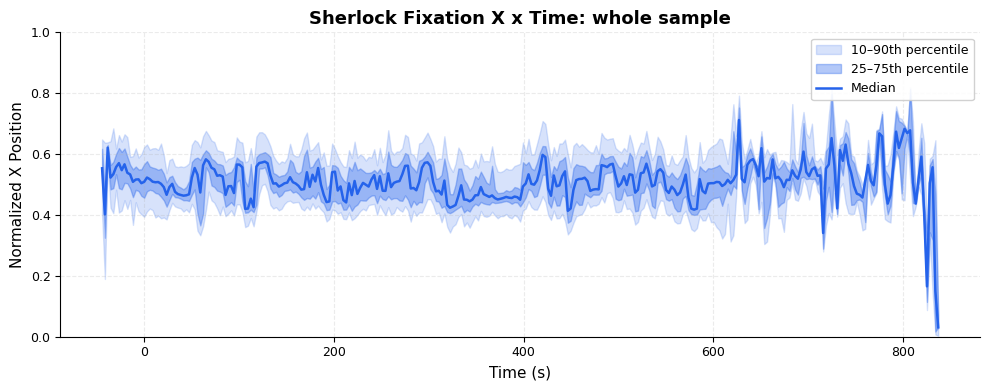

In [30]:
# --- Time bins & percentiles ---
time_bins = np.linspace(sherlock_combined_df["times"].min(), sherlock_combined_df["times"].max(), 300)

sherlock_combined_df["time_bin"] = pd.cut(sherlock_combined_df["times"], bins=time_bins, labels=time_bins[:-1]).astype(float)

grouped = sherlock_combined_df.groupby("time_bin")["x_norm"]
t = grouped.median().index.values
median = grouped.median()
p10, p25, p75, p90 = grouped.quantile(0.10), grouped.quantile(0.25), grouped.quantile(0.75), grouped.quantile(0.90)

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 4))

ax.fill_between(t, p10, p90, alpha=0.18, color="#2563eb", label="10–90th percentile")
ax.fill_between(t, p25, p75, alpha=0.35, color="#2563eb", label="25–75th percentile")
ax.plot(t, median, color="#2563eb", linewidth=1.8, label="Median")

ax.set_xlabel("Time (s)", fontsize=11)
ax.set_ylabel("Normalized X Position", fontsize=11)
ax.set_title("Sherlock Fixation X x Time: whole sample", fontsize=13, fontweight="bold")
ax.set_ylim(0, 1)
# # Add lines: 1:57 and 2:28
# ax.axvline(x=117, color='red',linestyle='--')
# ax.axvline(x=148, color='red',linestyle='--')
ax.tick_params(labelsize=9)
ax.legend(fontsize=9, framealpha=0.9, loc="upper right")
ax.grid(True, alpha=0.25, linestyle="--")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
# plt.savefig("gaze_figure.png", dpi=300, bbox_inches="tight")
plt.show()

#### Ranked by ISC 

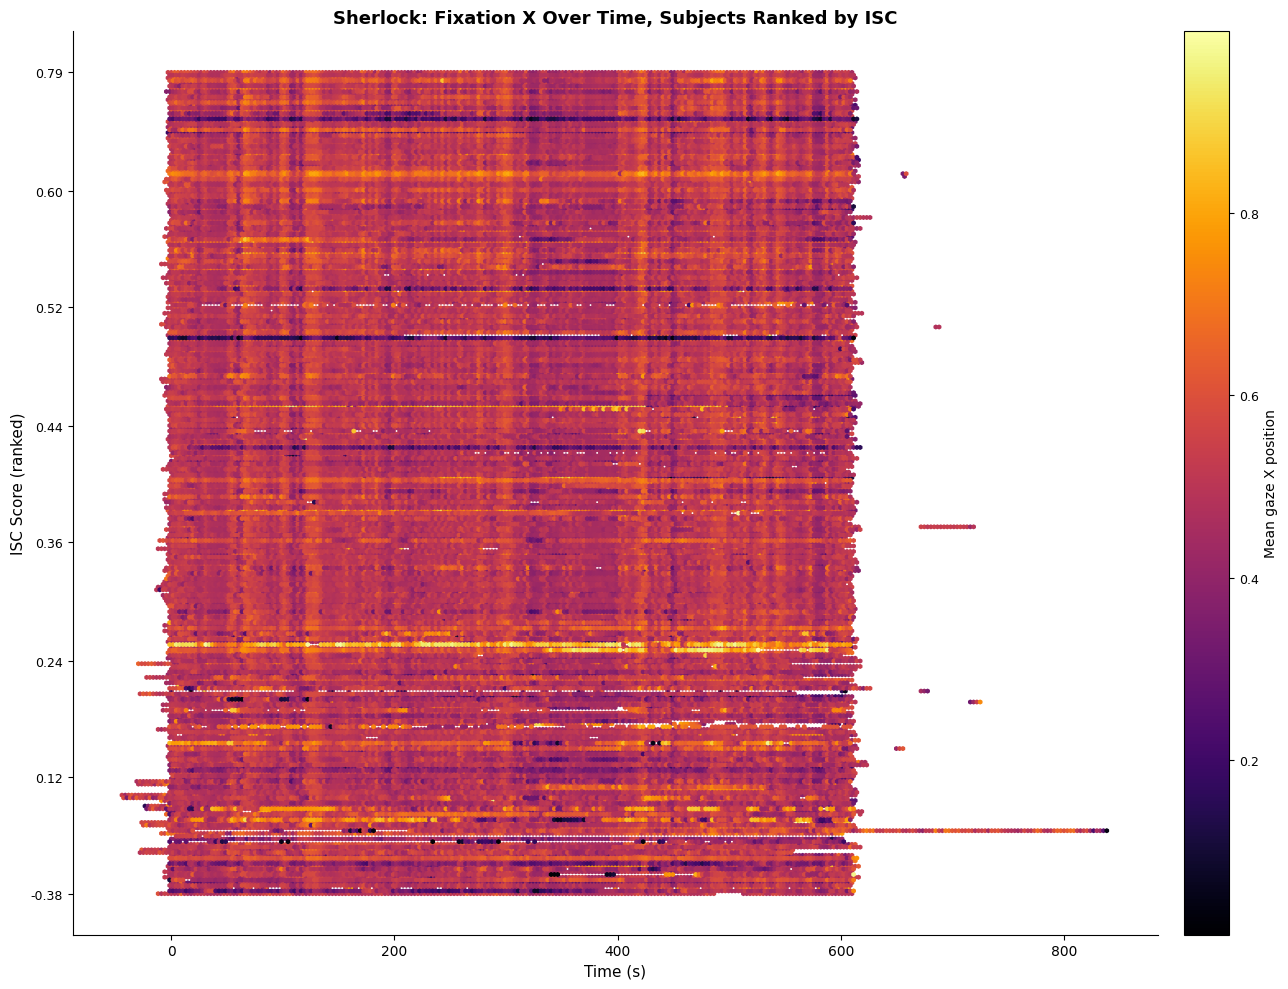

In [34]:
df = sherlock_combined_df.merge(isc_df_sherlock[["subjectID", "ISC_x", "rank_x"]], on="subjectID")

fig, ax = plt.subplots(figsize=(14, 10))

# Replace KDE loop with hexbin — fully vectorized, runs in seconds
hb = ax.hexbin(
    df["times"],
    df["rank_x"],
    C=df["x_norm"],          # color = mean x_norm in each hex cell
    gridsize=(300, 150),     # (x_bins, y_bins) — adjust for resolution
    cmap="inferno",
    reduce_C_function=np.mean,
    rasterized=True
)

cbar = fig.colorbar(hb, ax=ax, pad=0.02)
cbar.set_label("Mean gaze X position", fontsize=10)
cbar.ax.tick_params(labelsize=9)

# Y-axis: show ISC score values instead of rank integers
n_ticks = 8
# tick_ranks = np.linspace(0, df["rank_y"].max(), n_ticks, dtype=int)
tick_ranks = np.linspace(df["rank_x"].min(),
                         df["rank_x"].max(),
                         n_ticks,
                         dtype=int)
tick_labels = [f"{isc_df_sherlock.loc[isc_df_sherlock['rank_x'] == r, 'ISC_x'].values[0]:.2f}" for r in tick_ranks]
ax.set_yticks(tick_ranks)
ax.set_yticklabels(tick_labels, fontsize=9)

ax.set_xlabel("Time (s)", fontsize=11)
ax.set_ylabel("ISC Score (ranked)", fontsize=11)
ax.set_title("Sherlock: Fixation X Over Time, Subjects Ranked by ISC", fontsize=13, fontweight="bold")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
# plt.savefig("gaze_isc_ranked.pdf", dpi=300, bbox_inches="tight")
# plt.savefig("gaze_isc_ranked.png", dpi=300, bbox_inches="tight")
plt.show()

### Fixation Y x Time

#### Original Heatmap

In [ ]:
plt.figure(figsize=(8, 4))

plt.hexbin(
    sherlock_combined_df['times'],
    sherlock_combined_df['y_norm'],
    gridsize=100,
)

plt.colorbar(label='Density')
plt.xlim(-50,650)
plt.xlabel('Time')
plt.ylabel('Y position (pixels)')
plt.title('Sherlock: Fixation Y over Time')

plt.show()

#### Median and percentile looking

In [ ]:
# --- Time bins & percentiles ---
time_bins = np.linspace(sherlock_combined_df["times"].min(), sherlock_combined_df["times"].max(), 300)

sherlock_combined_df["time_bin"] = pd.cut(sherlock_combined_df["times"], bins=time_bins, labels=time_bins[:-1]).astype(float)

grouped = sherlock_combined_df.groupby("time_bin")["y_norm"]
t = grouped.median().index.values
median = grouped.median()
p10, p25, p75, p90 = grouped.quantile(0.10), grouped.quantile(0.25), grouped.quantile(0.75), grouped.quantile(0.90)

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 4))

ax.fill_between(t, p10, p90, alpha=0.18, color="#2563eb", label="10–90th percentile")
ax.fill_between(t, p25, p75, alpha=0.35, color="#2563eb", label="25–75th percentile")
ax.plot(t, median, color="#2563eb", linewidth=1.8, label="Median")

ax.set_xlabel("Time (s)", fontsize=11)
ax.set_ylabel("Normalized Y Position", fontsize=11)
ax.set_title("The Present Fixation Y x Time: whole sample", fontsize=13, fontweight="bold")
ax.set_ylim(0, 1)
# Add lines: 1:57 and 2:28
ax.axvline(x=117, color='red',linestyle='--')
ax.axvline(x=148, color='red',linestyle='--')
ax.tick_params(labelsize=9)
ax.legend(fontsize=9, framealpha=0.9, loc="upper right")
ax.grid(True, alpha=0.25, linestyle="--")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
# plt.savefig("gaze_figure.png", dpi=300, bbox_inches="tight")
plt.show()

#### Ranked by ISC

In [ ]:
df = sherlock_combined_df.merge(isc_df_sherlock[["subjectID", "ISC_y", "rank_y"]], on="subjectID")

fig, ax = plt.subplots(figsize=(14, 10))

# Replace KDE loop with hexbin — fully vectorized, runs in seconds
hb = ax.hexbin(
    df["times"],
    df["rank_y"],
    C=df["y_norm"],          # color = mean x_norm in each hex cell
    gridsize=(300, 150),     # (x_bins, y_bins) — adjust for resolution
    cmap="inferno",
    reduce_C_function=np.mean,
    rasterized=True
)

cbar = fig.colorbar(hb, ax=ax, pad=0.02)
cbar.set_label("Mean gaze Y position", fontsize=10)
cbar.ax.tick_params(labelsize=9)

# Y-axis: show ISC score values instead of rank integers
n_ticks = 8
# tick_ranks = np.linspace(0, df["rank_y"].max(), n_ticks, dtype=int)
tick_ranks = np.linspace(df["rank_y"].min(),
                         df["rank_y"].max(),
                         n_ticks,
                         dtype=int)
tick_labels = [f"{isc_df_sherlock.loc[isc_df_sherlock['rank_y'] == r, 'ISC_y'].values[0]:.2f}" for r in tick_ranks]
ax.set_yticks(tick_ranks)
ax.set_yticklabels(tick_labels, fontsize=9)

ax.set_xlabel("Time (s)", fontsize=11)
ax.set_ylabel("ISC Score (ranked)", fontsize=11)
ax.set_title("Sherlock: Fixation Y Over Time, Subjects Ranked by ISC", fontsize=13, fontweight="bold")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
# plt.savefig("gaze_isc_ranked.pdf", dpi=300, bbox_inches="tight")
# plt.savefig("gaze_isc_ranked.png", dpi=300, bbox_inches="tight")
plt.show()